# IPL Advance Data Analysis

In [1]:
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
ipl = pd.read_csv('../datasets/IPL.csv' , low_memory=False)

In [36]:
ipl.columns

Index(['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpire', 'umpires_call',
       'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner',
       'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season',
       'gender', 'team_type', 'superover_winner', 'result_type', 'method',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs',
       'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter',
       'striker_out'],
      dtype='object')

In [125]:
ipl['runs_bowler']

0         0
1         0
2         1
3         0
4         0
         ..
278200    0
278201    6
278202    4
278203    6
278204    6
Name: runs_bowler, Length: 278205, dtype: int64

In [3]:
ipl.head(5)

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


### Problem Statement:

#### Franchises want players who are both consistent and impactful. Identify batters who balance:

- High strike rate (aggression)
- High average (consistency)
- Tasks:
- Calculate:
- Strike Rate = runs / balls faced
- Average = runs / dismissals
- Filter players with:
- Minimum 500 runs
- Plot:
- Scatter Plot
- X-axis → Strike Rate
- Y-axis → Average
- Size → Total runs

In [4]:
bat = ipl.groupby('batter').agg(
    total_runs = ('runs_batter' , 'sum'),
    ball_faced = ('valid_ball' , 'sum'),
    matches_played = ('match_id' , 'nunique'),
    dismissals = ('striker_out' , lambda x : ((x == True)).sum())
).reset_index()

In [5]:
bat.sort_values(by='total_runs'  ,ascending=False).head(20)
# Here you can see that i have taken out top 20 batsman based on total runs scored in IPL History

,batter,total_runs,ball_faced,matches_played,dismissals
658,V Kohli,8671,6505,259,217
500,RG Sharma,7048,5317,266,235
535,S Dhawan,6769,5304,221,187
151,DA Warner,6567,4680,184,158
569,SK Raina,5536,4025,200,162
389,MS Dhoni,5439,3935,241,139
297,KL Rahul,5235,3836,135,112
31,AB de Villiers,5181,3400,170,122
51,AM Rahane,5032,4021,183,160
128,CH Gayle,4997,3331,141,125


In [15]:
# strike rate in code form

sr  = bat[bat['total_runs'] > 500].copy()
sr['strike_rate'] = (bat['total_runs'] / bat['ball_faced'])*100
bat['strike_rate'] = (bat['total_runs'] / bat['ball_faced'])*100

# as i will show you output that 'strike_rate' column will be added to our dataframe

# bat.sort_values(by='total_runs' , ascending=False).head(10)     # if sorted by total runs
sr.sort_values(by='strike_rate' , ascending=False).head(10)     # if sorted by strike rate

,batter,total_runs,ball_faced,matches_played,dismissals,strike_rate
469,Priyansh Arya,545,298,18,18,182.885906
449,PD Salt,1056,595,34,31,177.478992
40,AD Russell,2655,1508,114,90,176.061008
638,TH David,846,483,44,25,175.155280
643,TM Head,1146,667,37,32,171.814093
213,H Klaasen,1480,863,45,36,171.494786
412,N Pooran,2293,1355,86,66,169.225092
585,SP Narine,1780,1067,118,95,166.822868
632,T Stubbs,711,431,30,15,164.965197
71,Abhishek Sharma,1816,1108,74,66,163.898917


In [16]:
# in code form

avgg =  bat[bat['total_runs'] > 500].copy()
avgg['average'] = bat['total_runs'] / bat['dismissals']
bat['average'] = bat['total_runs'] / bat['dismissals']
# as i will show you output that 'average' column will be added to our dataframe

# avgg.sort_values(by='total_runs' , ascending=False).head(10)     # if sorted by total runs
# avgg.sort_values(by='strike_rate' , ascending=False).head(10)     # if sorted by strike rate
avgg.sort_values(by='average' , ascending=False).head(10)     # if sorted by average

,batter,total_runs,ball_faced,matches_played,dismissals,strike_rate,average
98,B Sai Sudharsan,1793,1220,40,35,146.967213,51.228571
632,T Stubbs,711,431,30,15,164.965197,47.400000
297,KL Rahul,5235,3836,135,112,136.470282,46.741071
174,DP Conway,1080,770,28,24,140.259740,45.000000
219,HM Amla,577,406,16,13,142.118227,44.384615
610,Shashank Singh,773,490,33,18,157.755102,42.944444
31,AB de Villiers,5181,3400,170,122,152.382353,42.467213
268,JP Duminy,2029,1631,75,48,124.402207,42.270833
431,OA Shah,506,388,22,12,130.412371,42.166667
495,RD Gaikwad,2502,1811,70,60,138.155715,41.700000


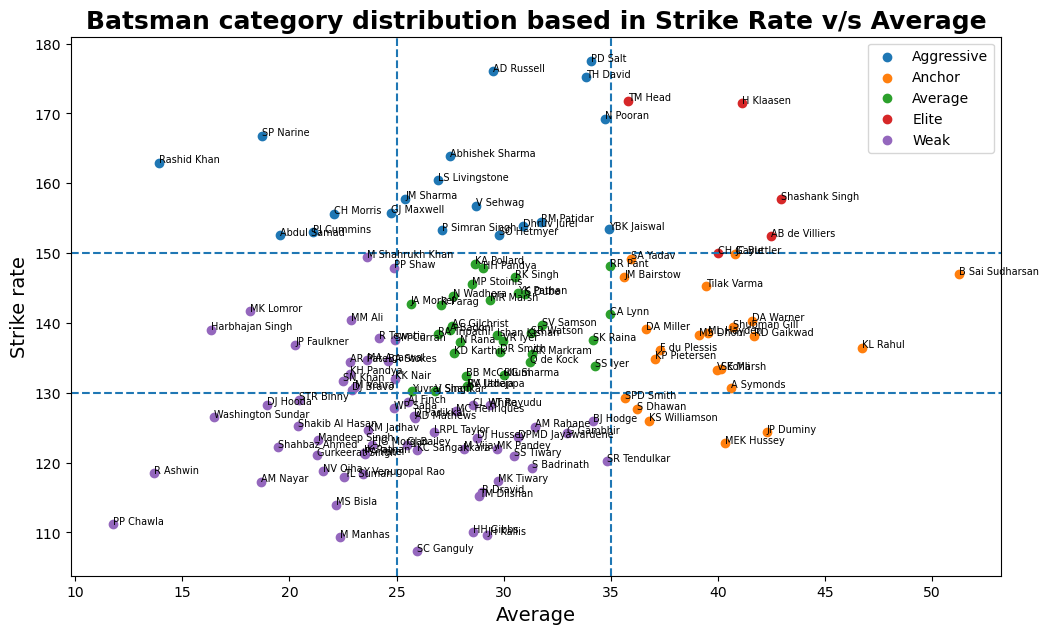

In [35]:
## Plotting of Strike Rate v/s Average


def category(row):
    if row['strike_rate'] >= 150 and row['average'] >= 35:
        return 'Elite'
    elif row['strike_rate'] >= 150:
        return 'Aggressive'
    elif row['average'] >= 35:
        return 'Anchor'
    elif row['strike_rate'] >= 130 and row['average'] >= 25:
        return 'Average'
    else:
        return 'Weak'

top = bat[((bat['ball_faced'] > 300) & (bat['matches_played'] > 30) & (bat['total_runs'] > 500))] .copy()
# top = top.sort_values(by='average', ascending=False).head(20)
top['category'] = top.apply(category, axis=1)


plt.figure(figsize=(12,7))

for cat, data in top.groupby('category'):
    plt.scatter(data['average'], data['strike_rate'], label=cat)




for i in range(len(top)):
    plt.text(
        top['average'].iloc[i],
        top['strike_rate'].iloc[i],
        top['batter'].iloc[i],
        fontsize=7
    )

plt.axvline(x=35, linestyle='--')
plt.axhline(y=150, linestyle='--')
plt.axhline(y=130, linestyle='--') 
plt.axvline(x=25, linestyle='--')

plt.legend()
plt.title("Batsman category distribution based in Strike Rate v/s Average" , fontsize=18 , fontweight='bold')   # It will add Title for our Bar Plot
plt.xlabel("Average" , fontsize=14)                        # It will lable our X-axis to 'Average'
plt.ylabel("Strike rate",fontsize=14)                       # It will lable our Y-axis to 'Strike rate'


plt.show()

## Bowler Economy Distribution (Box Plot)
📌 Problem Statement:

- Teams want bowlers who are not just economical on average but also consistent match-to-match.

🎯 Tasks:
- Calculate economy rate per match:
- runs conceded / overs
- For top bowlers (min 30 matches):
- Plot:
- Box Plot of economy rate per bowler

💡 Insight Goal:
- Identify:
- Bowlers with tight distribution (consistent)
- Bowlers with high variance (risky)

In [128]:
bowl = ipl.groupby('bowler').agg(
    runs_conceded = ('runs_bowler' , 'sum'),
    ball_bowled = ('valid_ball' , 'sum'),
    matches_played = ('match_id' , 'nunique'),
    bowler_wickets = ('bowler_wicket' , 'sum'),
    extra_balls = ('valid_ball' , lambda x : (x==0).sum()),
    dot_balls = ('runs_bowler' , lambda x : (x==0).sum())
).reset_index()

bowl['overs'] = ((bowl['ball_bowled']+bowl['extra_balls']) // 6 + ((bowl['ball_bowled']+bowl['extra_balls'])%6) / 10)
bowl['dotball%'] = (bowl['dot_balls'] / (bowl['ball_bowled']+bowl['extra_balls']))*100
bowl['economy'] = bowl['runs_conceded'] / bowl['overs']


In [129]:
bowl.sort_values(by=['bowler_wickets' , 'ball_bowled'] , ascending=[False,False]).head(20)

,bowler,runs_conceded,ball_bowled,matches_played,bowler_wickets,extra_balls,dot_balls,overs,dotball%,economy
543,YS Chahal,5032,3791,172,221,114,1319,650.5,33.777209,7.735588
72,B Kumar,5412,4222,190,198,156,1852,729.4,42.302421,7.419797
460,SP Narine,4933,4351,187,192,70,1720,736.5,38.905225,6.697895
359,PP Chawla,5108,3850,191,192,45,1358,649.1,34.865212,7.869358
369,R Ashwin,5652,4710,217,187,158,1663,811.2,34.161873,6.967456
200,JJ Bumrah,4059,3359,145,186,115,1428,579.0,41.105354,7.010363
121,DJ Bravo,4360,3120,158,183,176,1054,549.2,31.978155,7.938820
8,A Mishra,4145,3371,162,174,73,1220,574.0,35.423926,7.221254
387,RA Jadeja,5188,4056,225,170,71,1338,687.5,32.420645,7.546182
452,SL Malinga,3366,2827,122,170,147,1217,495.4,40.921318,6.794509


In [79]:
topBowlers = bowl[bowl['matches_played'] > 30]
topBowlers.sort_values(by=['bowler_wickets' , 'ball_bowled'] , ascending=[False,False]).head(20)

,bowler,runs_conceded,ball_bowled,matches_played,bowler_wickets,extra_balls,overs,economy
543,YS Chahal,5032,3791,172,221,114,650.5,7.735588
72,B Kumar,5412,4222,190,198,156,729.4,7.419797
460,SP Narine,4933,4351,187,192,70,736.5,6.697895
359,PP Chawla,5108,3850,191,192,45,649.1,7.869358
369,R Ashwin,5652,4710,217,187,158,811.2,6.967456
200,JJ Bumrah,4059,3359,145,186,115,579.0,7.010363
121,DJ Bravo,4360,3120,158,183,176,549.2,7.938820
8,A Mishra,4145,3371,162,174,73,574.0,7.221254
387,RA Jadeja,5188,4056,225,170,71,687.5,7.546182
452,SL Malinga,3366,2827,122,170,147,495.4,6.794509


Text(0, 0.5, 'Economy')

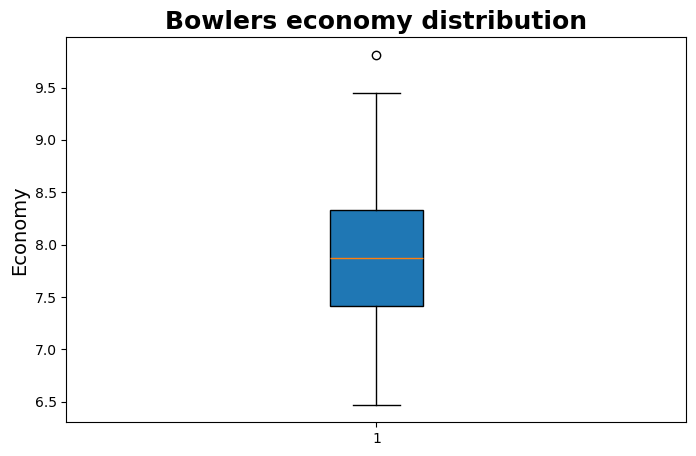

In [83]:
plt.figure(figsize=(8,5))

plt.boxplot(topBowlers['economy'],vert=True,patch_artist=True)
plt.title("Bowlers economy distribution" , fontsize=18 , fontweight='bold')            # It will add Title for our Bar Plot
                    
plt.ylabel("Economy",fontsize=14)   

## Best Death bowler

In [94]:
death = ipl[ipl['over'] >=16 ]

deathBowl = death.groupby('bowler').agg(
    runs_conceded = ('runs_bowler' , 'sum'),
    ball_bowled = ('valid_ball' , 'sum'),
    matches_played = ('match_id' , 'nunique'),
    bowler_wickets = ('bowler_wicket' , 'sum'),
    extra_balls = ('valid_ball' , lambda x : (x==0).sum())
).reset_index()


deathBowl['overs'] = ((deathBowl['ball_bowled']+deathBowl['extra_balls']) // 6 + ((deathBowl['ball_bowled']+deathBowl['extra_balls'])%6) / 10)
deathBowl = deathBowl[deathBowl['ball_bowled'] > 100]
deathBowl['economy'] = deathBowl['runs_conceded'] / deathBowl['overs']

In [95]:
deathBowl.sort_values(by=['economy' , 'bowler_wickets'] , ascending=[True,False]).head(20)

,bowler,runs_conceded,ball_bowled,matches_played,bowler_wickets,extra_balls,overs,economy
97,DE Bollinger,263,210,24,21,6,36.0,7.305556
352,SL Malinga,1196,917,109,90,48,160.5,7.451713
6,A Kumble,144,106,19,14,6,18.4,7.826087
359,SP Narine,1001,751,98,60,16,127.5,7.850980
368,SW Tait,175,126,17,12,8,22.2,7.882883
197,Kuldeep Yadav,255,186,29,19,8,32.2,7.919255
181,KH Pandya,144,106,20,14,3,18.1,7.955801
220,M Theekshana,140,102,16,11,5,17.5,8.000000
158,JJ Bumrah,1660,1195,131,86,48,207.1,8.015451
417,WD Parnell,266,189,25,15,10,33.1,8.036254


In [120]:
death = ipl[ipl['over'] >= 16]

death = death.groupby('batter').agg(
    total_runs = ('runs_batter' , 'sum'),
    ball_faced = ('valid_ball' , 'sum'),
    matches_played = ('match_id' , 'nunique'),
    dismissals = ('striker_out' , lambda x : ((x == True)).sum()),
    boundries = ('runs_batter', lambda x: ((x == 4) | (x == 6)).sum())
).reset_index()

death['boundry%'] = (death['boundries'] / death['ball_faced'])*100

death['strike_rate'] = (death['total_runs'] / death['ball_faced'])*100

death.sort_values(by=['total_runs' , 'boundries']  ,ascending=[False,False]).head(20)

,batter,total_runs,ball_faced,matches_played,dismissals,boundries,boundry%,strike_rate
340,MS Dhoni,2936,1548,184,86,406,26.227390,189.664083
252,KA Pollard,1708,928,117,69,237,25.538793,184.051724
257,KD Karthik,1565,830,117,66,233,28.072289,188.554217
433,RA Jadeja,1532,949,137,64,186,19.599579,161.433087
27,AB de Villiers,1421,604,75,35,218,36.092715,235.264901
190,HH Pandya,1241,661,87,46,174,26.323752,187.745840
439,RG Sharma,1176,595,76,50,173,29.075630,197.647059
34,AD Russell,1134,545,68,46,183,33.577982,208.073394
569,V Kohli,1121,557,72,42,151,27.109515,201.256732
131,DA Miller,1061,605,82,34,138,22.809917,175.371901


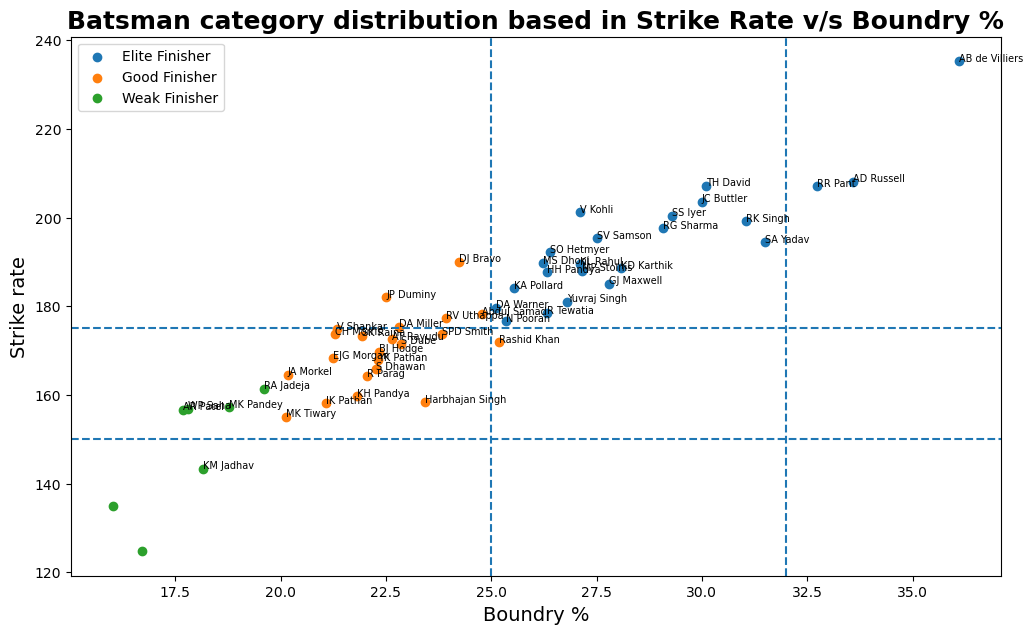

In [124]:
# Categorise the Batsmans into different categories

def category(row):
    if row['strike_rate'] >= 175 and row['boundry%'] >= 25:
        return 'Elite Finisher'
    elif row['strike_rate'] >= 150 and row['boundry%'] >= 20:
        return 'Good Finisher'
    else:
        return 'Weak Finisher'

death = death[(death['matches_played'] > 30) & (death['total_runs'] > 400)]
death['category'] = death.apply(category, axis=1)


plt.figure(figsize=(12,7))

for cat, data in death.groupby('category'):
    plt.scatter(data['boundry%'], data['strike_rate'], label=cat)

top = death.sort_values(by='strike_rate', ascending=False).head(50)

for i in range(len(top)):
    plt.text(
        top['boundry%'].iloc[i],
        top['strike_rate'].iloc[i],
        top['batter'].iloc[i],
        fontsize=7
    )

plt.axvline(x=32, linestyle='--')
plt.axhline(y=175, linestyle='--')
plt.axhline(y=150, linestyle='--') 
plt.axvline(x=25, linestyle='--')

plt.legend()
plt.title("Batsman category distribution based in Strike Rate v/s Boundry %" , fontsize=18 , fontweight='bold')   # It will add Title for our Bar Plot
plt.xlabel("Boundry %" , fontsize=14)                        # It will lable our X-axis to 'Boundry %'
plt.ylabel("Strike rate",fontsize=14)                       # It will lable our Y-axis to 'Strike rate'


plt.show()

#### Best Finisher := 

- Clearly AB Devilliers is the best finisher ranked here 

In [140]:
pressureBowl = bowl[bowl['bowler_wickets'] > 30]
pressureBowl.sort_values(by=['dotball%' , 'bowler_wickets'] , ascending=[False,False]).head(20)

,bowler,runs_conceded,ball_bowled,matches_played,bowler_wickets,extra_balls,dot_balls,overs,dotball%,economy
141,DW Steyn,2523,2182,95,97,100,1064,380.2,46.625767,6.635981
395,RJ Harris,1047,832,37,45,33,390,144.1,45.086705,7.265788
119,DE Bollinger,693,576,27,37,24,270,100.0,45.000000,6.930000
298,MM Patel,1698,1355,63,74,27,612,230.2,44.283647,7.376195
431,S Sreesanth,1194,880,44,40,67,416,157.5,43.928194,7.580952
209,JR Hazlewood,1196,867,39,57,25,390,148.4,43.721973,8.059299
345,P Kumar,3251,2524,119,90,113,1147,439.3,43.496397,7.400410
270,M Morkel,2089,1629,70,77,70,738,283.1,43.437316,7.379018
332,NM Coulter-Nile,1100,857,38,48,35,387,148.4,43.385650,7.412399
191,JC Archer,1602,1218,52,59,61,552,213.1,43.158718,7.517597


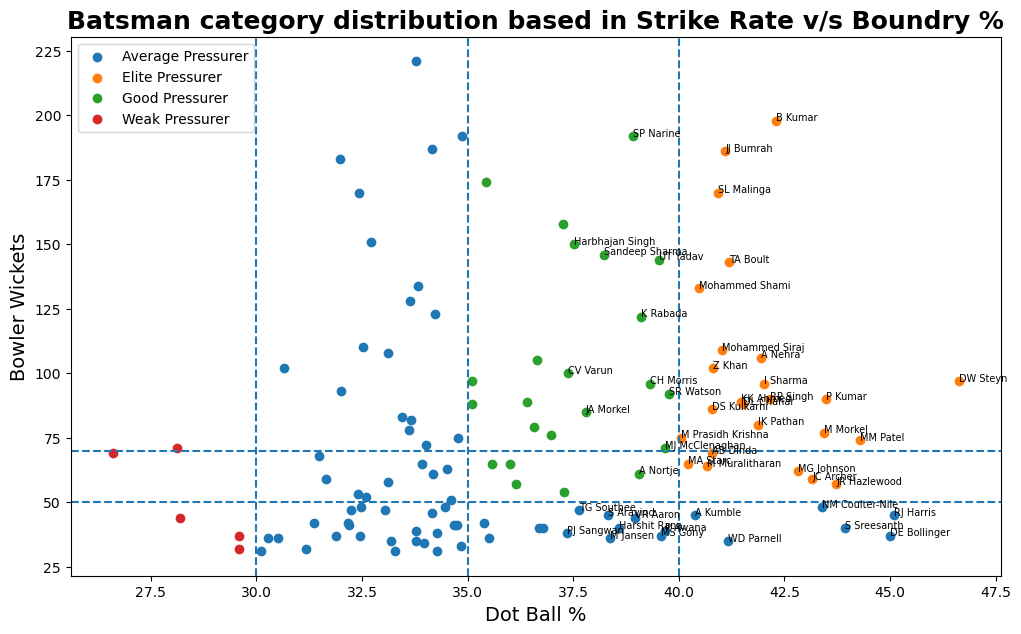

In [145]:
# Categorise the Batsmans into different categories

def category(row):
    if row['bowler_wickets'] >= 50 and row['dotball%'] >= 40:
        return 'Elite Pressurer'
    elif row['bowler_wickets'] >= 50 and row['dotball%'] >= 35:
        return 'Good Pressurer'
    elif row['bowler_wickets'] >= 30 and row['dotball%'] >= 30:
        return 'Average Pressurer'
    else:
        return 'Weak Pressurer'

pressureBowl = pressureBowl[pressureBowl['bowler_wickets'] > 30]
pressureBowl['category'] = pressureBowl.apply(category, axis=1)


plt.figure(figsize=(12,7))

for cat, data in pressureBowl.groupby('category'):
    plt.scatter(data['dotball%'], data['bowler_wickets'], label=cat)

top = pressureBowl.sort_values(by='dotball%', ascending=False).head(50)

for i in range(len(top)):
    plt.text(
        top['dotball%'].iloc[i],
        top['bowler_wickets'].iloc[i],
        top['bowler'].iloc[i],
        fontsize=7
    )

plt.axvline(x=30, linestyle='--')
plt.axhline(y=70, linestyle='--')
plt.axhline(y=50, linestyle='--') 
plt.axvline(x=35, linestyle='--')
plt.axvline(x=40, linestyle='--')

plt.legend()
plt.title("Batsman category distribution based in Strike Rate v/s Boundry %" , fontsize=18 , fontweight='bold')   # It will add Title for our Bar Plot
plt.xlabel("Dot Ball %" , fontsize=14)                        # It will lable our X-axis to 'Boundry %'
plt.ylabel("Bowler Wickets",fontsize=14)                       # It will lable our Y-axis to 'Strike rate'


plt.show()

### Pressurer :=

- We can see that Bhuvneshwar Kumar, Jaspreet Bumrah ,  Dale Steyn are  who creates most pressure